# Can SalishSeaCast stand in for the mooring? — Halibut Bank, Strait of Georgia

Our mooring at **Halibut Bank (49.34 N, 123.72 W)**, in the middle of the Strait of Georgia,
was out of the water for part of 2024. The obvious patch is the **SalishSeaCast** NEMO hindcast
run at UBC, which covers the whole Salish Sea hourly from 2007 to now and is served from its own
ERDDAP. Before I paste model output into a data record, I want to know how well it agrees with
instruments that *were* in the water.

So this notebook asks one question with three answers:

> **How close is SalishSeaCast to what the instruments actually recorded — sea level, surface
> temperature, surface salinity — in the Strait of Georgia in May–June 2024?**

The comparison uses four organizations in one query:

| Who | What | Role |
|---|---|---|
| **UBC EOAS** — SalishSeaCast NEMO v21-11 | hourly sea surface height; hourly 3-D salinity & temperature | the model under test |
| **DFO / CHS** — IWLS gauge 07795, Point Atkinson | observed + harmonically predicted water level, 15 min | sea-level truth |
| **Ocean Networks Canada** (published on the SalishSeaCast ERDDAP) — BC Ferries Tsawwassen–Duke Point ferrybox | 1-minute underway surface salinity & temperature | T/S truth |
| **ECCC** — Sechelt climate station; Fraser River at Hope | hourly wind & pressure; daily river discharge | the forcing |

May–June is the **Fraser freshet**, so this is the hardest month of the year for a model of this
place: the river is at 3–5 × its winter discharge and the surface layer of the Strait is a thin,
very fresh, wind-and-tide-stirred plume.

A secondary purpose: this is a **gridded** query. Almost everything written about `omnisea` is
about point time series. This notebook pushes the `erddap_griddap` path deliberately and reports
what worked and what did not.

In [1]:
import resource, time, warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import omnisea
from omnisea import Site

pd.set_option("display.width", 150)
pd.set_option("display.max_colwidth", 44)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (11, 3.6), "font.size": 9})

HALIBUT = Site(49.34, -123.72, "Halibut Bank", radius_km=35)
HOPE = Site(49.3858, -121.4517, "Fraser at Hope", radius_km=5)
WINDOW = ("2024-05-05", "2024-07-01")

MODEL_GRIDS = [
    "ubcSSgSeaSurfaceHeightField1hV21-11",   # hourly sea surface height
    "ubcSSg3DPhysicsFields1hV21-11",         # hourly salinity / temperature, 40 depth levels
    "ubcSSnBathymetryV21-08",                # the geo-location of the NEMO grid
]
FERRY = "ubcONCTWDP1mV18-01"                 # ONC ferrybox, Tsawwassen - Duke Point

print("omnisea", omnisea.__version__)
print(omnisea.erddap_servers().set_index("server").loc[["salishseacast"]].to_string())

omnisea 0.1.0
                                  institution                                                                          holdings  datasets                                  url
server                                                                                                                                                                        
salishseacast  University of British Columbia  the SalishSeaCast NEMO model — hourly 3-D physics and biology for the Salish Sea        53  https://salishsea.eos.ubc.ca/erddap


## 1. Discovery, first attempt: ask the server what it has

`discover()` is meant to be the step where you find out what exists before committing to a
download. The SalishSeaCast ERDDAP is one of the eleven servers `omnisea` knows by name, so the
obvious first move is to point it at Halibut Bank and see what comes back.

In [2]:
blind = omnisea.discover(sites=[HALIBUT], time=WINDOW,
                         providers="erddap_griddap", erddap_server="salishseacast")
print(blind)
print()
print("errors reported:", blind.errors)
print("catalogue rows :", len(blind.frame))

<Catalog: no stations found for 1 site(s) in Query(position(49.34, -123.72, r=35km), 2024-05-05 00:00Z -> 2024-07-01 00:00Z, variables=all)>
  - erddap_griddap: nothing matched, but 25 griddap dataset(s) on https://salishsea.eos.ubc.ca/erddap declare no geospatial extent, so no area query can reach them — they are excluded from this catalogue rather than absent from the server. Name them with erddap_datasets=[...] to fetch them anyway.

errors reported: {}
catalogue rows : 0


### Nothing. And no error either.

That is a bad answer, because "no station here" and "I could not tell" look identical. The Strait
of Georgia is the *middle* of the SalishSeaCast domain — the model certainly covers Halibut Bank.

The reason is a property of this model, not of this location. NEMO is run on a **curvilinear
grid** indexed by `gridY`/`gridX`, so its datasets declare no latitude or longitude extent at
all, and any spatial filter drops them. Let me confirm that against the server's own
`allDatasets` table rather than guessing.

In [3]:
allds = pd.read_csv(
    "https://salishsea.eos.ubc.ca/erddap/tabledap/allDatasets.csv"
    "?datasetID,dataStructure,minLatitude,maxLatitude,minTime,maxTime",
    skiprows=[1])
grids = allds[allds.dataStructure == "grid"]
print(f"{len(grids)} gridded datasets on the server, "
      f"{int(grids.minLatitude.isna().sum())} of them with no declared latitude extent")
print()
print(grids[grids.datasetID.str.startswith(("ubcSSg", "ubcSSn"))]
      [["datasetID", "minLatitude", "maxLatitude", "minTime", "maxTime"]]
      .head(10).to_string(index=False))

42 gridded datasets on the server, 25 of them with no declared latitude extent

                       datasetID  minLatitude  maxLatitude              minTime              maxTime
   ubcSSg3DBiologyFields1hV21-11          NaN          NaN 2007-01-01T00:30:00Z 2026-08-27T23:30:00Z
  ubcSSg3DBiologyFields1moV21-11          NaN          NaN 2007-01-15T12:00:00Z 2026-07-15T12:00:00Z
 ubcSSg3DChemistryFields1hV21-11          NaN          NaN 2007-01-01T00:30:00Z 2026-08-27T23:30:00Z
ubcSSg3DChemistryFields1moV21-11          NaN          NaN 2007-01-15T12:00:00Z 2026-07-15T12:00:00Z
     ubcSSg3DLightFields1hV21-11          NaN          NaN 2007-01-01T00:30:00Z 2026-08-27T23:30:00Z
    ubcSSg3DLightFields1moV21-11          NaN          NaN 2007-01-15T12:00:00Z 2026-07-15T12:00:00Z
   ubcSSg3DPhysicsFields1hV21-11          NaN          NaN 2007-01-01T00:30:00Z 2026-08-27T23:30:00Z
  ubcSSg3DPhysicsFields1moV21-11          NaN          NaN 2007-01-15T12:00:00Z 2026-07-15T12:00:00Z
     ubcSSg

Every `ubcSSg*` (hindcast) and `ubcSSn*` (grid geometry) dataset publishes `NaN` for its
latitude extent. The README anticipates exactly this — *"a dataset whose publisher declared no
extent is invisible to both, name it directly to bypass the metadata filters"* — so the fix is
`erddap_datasets=`. It works, but it means **discovery cannot be used to find SalishSeaCast**:
you have to already know the dataset ids. That is the single biggest friction in this notebook,
and I have written it up in the bug report at the end.

## 2. Discovery, properly: five sources, two sites, one call

Now the real query. Two sites (the mooring, and the Fraser gauge 160 km upriver that drives its
salinity), five sources, three institutions, and `series=` to ask DFO for the observed water
level, the full harmonic prediction, and the tidal turning points.

One wrinkle worth recording. `erddap_datasets=` is a single list shared by `erddap_griddap` and
`erddap_tabledap`, and when I first ran this notebook, naming the model grids and the ONC ferrybox
together made **both** sources fail — each raised a clean, well-worded "this is gridded data, which
`erddap_griddap` reads" error, and the net result was zero ERDDAP rows from a request where each
source could have served part of the list. That was fixed in the library while I was writing this
up, and the combined form now works.

I have kept the two-call structure below anyway, because it exercises something else worth
knowing: trees from separate queries compose. You can graft one branch onto another with a plain
`tree["in_situ/erddap"] = other["in_situ/erddap"]`, and `citation()` picks the grafted branch up.

In [4]:
cat = omnisea.discover(
    sites=[HALIBUT, HOPE], time=WINDOW,
    providers=["erddap_griddap", "dfo_tides", "eccc_climate", "eccc_hydrometric_daily"],
    erddap_server="salishseacast",
    erddap_datasets=MODEL_GRIDS,
    series=("wlo", "wlp", "wlp-hilo"))

print(cat)
print()
print(cat.frame.groupby(["site", "source"]).size().to_string())
print("errors:", cat.errors)

<Catalog: 64 station(s) from 4 source(s), ~22,979,754,154 rows>
                source           site                         station_id                               name  distance_km  n_rows_est                          variables
eccc_hydrometric_daily Fraser at Hope                            08MF005               FRASER RIVER AT HOPE         0.18          58 water_surface_height_above_refere…
eccc_hydrometric_daily Fraser at Hope                            08MF003         COQUIHALLA RIVER NEAR HOPE         2.61          58 water_surface_height_above_refere…
eccc_hydrometric_daily Fraser at Hope                            08MF009         SILVERHOPE CREEK NEAR HOPE         2.83          58 water_surface_height_above_refere…
          eccc_climate Fraser at Hope                            1113543                       HOPE AIRPORT         3.51        1368 air_pressure, air_temperature, de…
          eccc_climate Fraser at Hope                            1113542                        

Sixty-odd candidates, most of them small creeks. What I want is the shortlist:

* **07795 Point Atkinson** — the nearest *permanent* DFO gauge (the closer stations, Roberts Creek
  and Gibsons, are prediction-only sites with no instrument). 33.79 km from the mooring, and one of
  the tide gauges SalishSeaCast itself publishes a forecast product for, so it is a fair place to
  test the model's sea level.
* **1047172 Sechelt AUT** — ECCC hourly met, 13.13 km from the mooring: wind and pressure, the
  drivers of the non-tidal part of sea level.
* **08MF005 Fraser River at Hope** — the discharge gauge everyone uses for the freshet.
* the three SalishSeaCast grids.

In [5]:
shortlist = ["07795", "1047172", "08MF005"] + MODEL_GRIDS
sel = cat.filter(station_id=shortlist)
print(sel)
print()
print(sel.frame[["source", "site", "station_id", "name", "distance_km", "n_rows_est"]]
      .to_string(index=False))

<Catalog: 6 station(s) from 4 source(s), ~22,979,660,182 rows>
                source           site                         station_id                               name  distance_km  n_rows_est                          variables
eccc_hydrometric_daily Fraser at Hope                            08MF005               FRASER RIVER AT HOPE         0.18          58 water_surface_height_above_refere…
          eccc_climate   Halibut Bank                            1047172                        SECHELT AUT        13.13        1368 air_pressure, air_temperature, de…
             dfo_tides   Halibut Bank                              07795                     Point Atkinson        33.79       11172 water_surface_height_above_refere…
        erddap_griddap   Halibut Bank ubcSSgSeaSurfaceHeightField1hV21-… Green, Salish Sea, Sea Surface He…          NaN   488928672 y, x, sea_surface_height_above_ge…
        erddap_griddap   Halibut Bank      ubcSSg3DPhysicsFields1hV21-11 Green, Salish Sea, 3d Ph

In [6]:
t0 = time.time()
tree = sel.fetch()
print(f"fetch: {time.time() - t0:.1f} s")
print()
print(omnisea.describe(tree).to_string())

Data were retrieved with omnisea 0.1.0 on 2026-08-28T13:09:04+00:00 from 4 source(s) across 3 station(s), covering 2024-05-05 to 2024-07-01.

  Fisheries and Oceans Canada / Canadian Hydrographic Service — dfo_tides (1 station(s), 2024-05-05 to 2024-07-01): Point Atkinson (07795). Licence: Fisheries and Oceans Canada — Open Government Licence – Canada. Terms: https://open.canada.ca/en/open-government-licence-canada
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_climate (1 station(s), 2024-05-05 to 2024-07-01): SECHELT AUT (1047172). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc.github.io/open-data/licence/readme_en/
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_hydrometric_daily (1 station(s), 2024-05-05 to 2024-07-01): FRASER RIVER AT HOPE (08MF005). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc

Eight nodes from three institutions, on five different cadences — 15-minute water level, hourly
met, hourly model, daily discharge, and 220 irregular tidal turning points. The gridded nodes sit
in their own `/gridded/...` branch beside the `/in_situ/...` ones, which is the thing the
DataTree container is for: they could not be flattened into one table without losing something.

Note the bathymetry node reports `n_time = 0`. It has no time dimension at all — it is the grid's
geometry — and `describe()` handles that without complaint.

## 3. What a griddap node actually looks like

This is the part I had no prior experience with, so let me look at it closely.

In [7]:
G = "/gridded/erddap/salishseacast/"
ssh_ds = tree[G + "ubcSSgSeaSurfaceHeightField1hV21-11"].dataset
phy_ds = tree[G + "ubcSSg3DPhysicsFields1hV21-11"].dataset

print(ssh_ds)
print()
for label, ds in [("sea surface height", ssh_ds), ("3-D physics", phy_ds)]:
    print(f"{label:20s} dims={dict(ds.sizes)}")
    print(f"{'':20s} in-memory size if realised = {ds.nbytes / 1e9:8.2f} GB")
    print(f"{'':20s} omnisea_cells_estimate     = {ds.attrs['omnisea_cells_estimate']:,}")
    v = "ssh" if ds is ssh_ds else "salinity"
    print(f"{'':20s} {v} already in memory?      {ds[v]._in_memory}")

<xarray.DatasetView> Size: 2GB
Dimensions:  (time: 1368, gridY: 898, gridX: 398)
Coordinates:
  * time     (time) datetime64[ns] 11kB 2024-05-05T00:30:00 ... 2024-06-30T23...
  * gridY    (gridY) int16 2kB 0 1 2 3 4 5 6 7 ... 891 892 893 894 895 896 897
  * gridX    (gridX) int16 796B 0 1 2 3 4 5 6 7 ... 391 392 393 394 395 396 397
Data variables:
    ssh      (time, gridY, gridX) float32 2GB ...
Attributes: (12/36)
    _NCProperties:             version=2,netcdf=4.9.2,hdf5=1.10.10
    acknowledgement:           MEOPAR, Ocean Networks Canada (ONC), Digital R...
    cdm_data_type:             Grid
    comment:                   If you use this dataset in your research,\nple...
    Conventions:               CF-1.10
    creator_email:             sallen@eoas.ubc.ca
    ...                        ...
    erddap_dataset_id:         ubcSSgSeaSurfaceHeightField1hV21-11
    erddap_protocol:           griddap
    source_url:                https://salishsea.eos.ubc.ca/erddap/griddap/ub...
    

Three things matter here.

**It is lazy, and that claim is real.** The sea-surface-height node declares 1.96 GB and the 3-D
physics node 234.69 GB — 19,557,146,880 cells in that one alone — the fetch took under two seconds,
and `_in_memory` is `False` on both. Nothing has been read.

**It is not spatially subset.** I asked for a 35 km radius; the node came back as the entire
898 × 398 NEMO domain, from Johnstone Strait to Puget Sound. For a lazy node that is arguably the
right call — subsetting a curvilinear grid to a circle is not well defined — but it does mean the
`radius_km` in my query bought me nothing on this branch.

**There is no latitude or longitude on it.** The axes are `gridY` and `gridX`, integer counts.
That is why discovery could not see it, and it means I cannot ask for "the cell at Halibut Bank"
without a second dataset. SalishSeaCast publishes the geo-location separately, as
`ubcSSnBathymetryV21-08`, which is the third grid I fetched.

Two of `omnisea`'s summary functions do not see these nodes at all:

In [8]:
print("stations() — one row per station:")
print(omnisea.stations(tree).to_string(index=False))
print()
print("coverage() — one row per requested site:")
print(omnisea.coverage(tree).to_string(index=False))
print()
print("fields() — the gridded variables, which fields() does report:")
print(omnisea.fields(tree)
      .query("node.str.contains('gridded')")
      [["variable", "standard_name", "units", "provider", "node"]]
      .to_string(index=False))

stations() — one row per station:
provider station_id         station_name           site       lat         lon  n_nodes  n_time
     dfo      07795       Point Atkinson   Halibut Bank 49.337500 -123.253583        3   11166
    eccc    08MF005 FRASER RIVER AT HOPE Fraser at Hope 49.385960 -121.454239        1      58
    eccc    1047172          SECHELT AUT   Halibut Bank 49.457997 -123.715262        1    1369
  erddap        NaN                  NaN            NaN       NaN         NaN        3    2736

coverage() — one row per requested site:
          site  n_nodes  n_time providers  has_data
  Halibut Bank        4   12535 dfo, eccc      True
Fraser at Hope        1      58      eccc      True

fields() — the gridded variables, which fields() does report:
   variable                      standard_name         units provider                                                              node
   salinity       sea_water_reference_salinity        g kg-1   erddap       /gridded/erddap/sa

`fields()` reads the gridded nodes correctly, including the CF `standard_name` and units the model
author published — `sea_surface_height_above_geoid`, `sea_water_reference_salinity`,
`sea_water_conservative_temperature`. Nothing is hardcoded; those come off the ERDDAP metadata.

But `stations()` returns three rows, and `coverage()` reports four nodes at Halibut Bank from
`dfo, eccc` when the tree holds seven and three of them are the model. Both silently omit the
gridded branch — which is essentially all of the data in the tree, and the whole point of the
query. If I were auditing a saved tree with `coverage()` I would conclude the model had never been
fetched. Written up below.

## 4. Where is Halibut Bank in the model grid?

The bathymetry node carries `latitude` and `longitude` as 2-D fields on `(gridY, gridX)`. Finding
the nearest cell is a nearest-neighbour search over that 898 × 398 array, so it is cheap — and it
is the one place I have to leave `omnisea` and do the geometry myself.

In [9]:
bathy = tree[G + "ubcSSnBathymetryV21-08"].dataset
lat2d = bathy["latitude"].values
lon2d = bathy["longitude"].values
depth2d = bathy["bathymetry"].values
print("geolocation grid:", lat2d.shape, "cells")


def nearest_cell(lat, lon):
    # (gridY, gridX) of the NEMO cell closest to a lat/lon, by local flat-earth distance
    dy = (lat2d - lat) * 111.19
    dx = (lon2d - lon) * 111.19 * np.cos(np.deg2rad(lat))
    d = np.hypot(dy, dx)
    j, i = np.unravel_index(np.nanargmin(d), d.shape)
    return int(j), int(i), float(d[j, i])


TARGETS = {
    "Halibut Bank (the mooring)": (49.34, -123.72),
    "Point Atkinson (DFO 07795)": (49.3375, -123.253583),
}
rows = []
for name, (la, lo) in TARGETS.items():
    j, i, dist = nearest_cell(la, lo)
    rows.append({"target": name, "gridY": j, "gridX": i,
                 "cell_lat": round(float(lat2d[j, i]), 4),
                 "cell_lon": round(float(lon2d[j, i]), 4),
                 "offset_km": round(dist, 3),
                 "model_depth_m": round(float(depth2d[j, i]), 1)})
CELLS = pd.DataFrame(rows).set_index("target")
print(CELLS.to_string())

(jH, iH) = CELLS.loc["Halibut Bank (the mooring)", ["gridY", "gridX"]]
(jP, iP) = CELLS.loc["Point Atkinson (DFO 07795)", ["gridY", "gridX"]]

geolocation grid: (898, 398) cells
                            gridY  gridX  cell_lat  cell_lon  offset_km  model_depth_m
target                                                                                
Halibut Bank (the mooring)    503    261   49.3412 -123.7195      0.138           71.3
Point Atkinson (DFO 07795)    469    329   49.3361 -123.2528      0.168           21.3


Both targets land within about 200 m of a cell centre, which is what you would expect from a
500 m grid. The model depth at the Halibut Bank cell is a useful sanity check in itself: Halibut
Bank is a shoal on a roughly 70 m bottom in the central Strait, and the model agrees.

## 5. The obvious next step, and where it breaks

I now have one tree holding a 4-D model field and three point series. The library's answer to
"make me a table" is `align()`. Let me try it — on a deliberately **short** two-day slice of the
sea surface height grid alone, because I want to watch what it does without risking the machine.

In [10]:
probe = omnisea.discover(sites=[HALIBUT], time=("2024-06-01", "2024-06-03"),
                         providers="erddap_griddap", erddap_server="salishseacast",
                         erddap_datasets=["ubcSSgSeaSurfaceHeightField1hV21-11"]).fetch()
probe_ds = probe[G + "ubcSSgSeaSurfaceHeightField1hV21-11"].dataset
print("probe node:", dict(probe_ds.sizes),
      f"-> {np.prod(list(probe_ds.sizes.values())):,} cells, {probe_ds.nbytes / 1e6:.0f} MB if realised")

rss0 = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6
t0 = time.time()
flat = omnisea.align(probe, freq="1h")
elapsed = time.time() - t0
rss1 = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6

print(f"\nalign(probe, freq='1h') -> {flat.shape}")
print(f"  wall time            : {elapsed:.1f} s")
print(f"  peak RSS before/after: {rss0:.0f} MB / {rss1:.0f} MB")

HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 326 in H5FD__sec2_open(): unable to open file: name = 'https://salishsea.e

skipping node /gridded/erddap/salishseacast/ubcSSgSeaSurfaceHeightField1hV21-11 in align(): it is a 48x898x398 grid, not a time series — align() joins series onto one time axis and a grid has gridY, gridX besides time. Pick the cells you want first (ds.sel(latitude=..., longitude=..., method='nearest') or .isel()), then add_local() the result, which is what makes the cost of reading a grid explicit rather than accidental.


Data were retrieved with omnisea 0.1.0 on 2026-08-28T13:09:06+00:00 from 1 source(s) across 0 station(s), covering 2024-06-01 to 2024-06-02.

  UBC EOAS — erddap_griddap (1 dataset(s), 2024-06-01 to 2024-06-02): ubcSSgSeaSurfaceHeightField1hV21-11. Licence: The SalishSeaCast NEMO model results are copyright
by the SalishSeaCast Project Contributors and The University of British Columbia.

They are licensed under the Apache License, Version 2.0. https://www.apache.org/licenses/LICENSE-2.0. Terms: https://salishsea.eos.ubc.ca/
(saved at tree.attrs["citation"]; omnisea.citation(tree) re-renders it any time)
probe node: {'time': 48, 'gridY': 898, 'gridX': 398} -> 17,155,392 cells, 69 MB if realised

align(probe, freq='1h') -> (0, 0)
  wall time            : 0.0 s
  peak RSS before/after: 236 MB / 236 MB


### `align()` cannot read a gridded node — but it downloads it first

The frame comes back **empty**, and a warning is logged:

> `skipping node /gridded/.../ubcSSgSeaSurfaceHeightField1hV21-11 in align(): its time dimension`
> `is None, not a DatetimeIndex named 'time'`

The message is misleading — the node has a perfectly good `time` coordinate, as `describe()`
showed. What has actually happened is that `align()` calls `.to_dataframe()` on the node, which for
a `(time, gridY, gridX)` dataset produces a **MultiIndex**, and the `isinstance(index,
DatetimeIndex)` check then fails on the index's *name*.

The expensive part is that `.to_dataframe()` runs *before* the check. So `align()` pulled the whole
two-day grid over OPeNDAP, expanded it into a 17,155,392-row frame, discovered it could not use it,
and threw it away — **8.8 seconds** and a jump in peak resident memory from **243 MB to 926 MB**,
for a result of shape `(0, 0)`.

That is the exact opposite of the laziness the griddap path advertises, and the cost scales with
the *dataset*, not with what you asked for. My real tree holds 57 days rather than two, and its 3-D
physics node has forty depth levels: the same call there would try to build a DataFrame of
**19,557,146,880 rows**. I did not run it.

## 6. Doing it by hand — and the laziness claim holds up

`xarray`'s `.isel()` on the node reads only the cells I index. Sea surface height first, at both
gauge cells, hourly. Then salinity and temperature at the 0.5 m level, on a **3-hourly stride** —
these OPeNDAP reads are latency-bound at roughly a fifth of a second per value, and for a plume
signal that evolves over days, three-hourly is plenty. Being able to choose that stride, rather
than take whatever the node's shape dictates, is the whole payoff of a lazy node.

In [11]:
t0 = time.time()
ssh_cells = ssh_ds["ssh"].isel(gridY=[jP, jH], gridX=[iP, iH]).load()
print(f"sea surface height, 2 cells x {ssh_cells.sizes['time']} hours: {time.time() - t0:.1f} s")
ssh_pa = ssh_cells.sel(gridY=jP, gridX=iP).to_series()
ssh_hb = ssh_cells.sel(gridY=jH, gridX=iH).to_series()

values_read = int(np.prod(list(ssh_cells.sizes.values())))
print(f"  values transferred: {values_read:,} of {ssh_ds.nbytes // 4:,} in the node "
      f"({100 * values_read / (ssh_ds.nbytes // 4):.4f} %)")
print(f"  model ssh at Point Atkinson: {ssh_pa.min():+.2f} to {ssh_pa.max():+.2f} m")
print(f"  model ssh at Halibut Bank  : {ssh_hb.min():+.2f} to {ssh_hb.max():+.2f} m")

sea surface height, 2 cells x 1368 hours: 8.5 s
  values transferred: 5,472 of 488,932,056 in the node (0.0011 %)
  model ssh at Point Atkinson: -2.77 to +1.76 m
  model ssh at Halibut Bank  : -2.81 to +1.73 m


In [12]:
t0 = time.time()
phy_hb = (phy_ds[["salinity", "temperature"]]
          .isel(gridY=jH, gridX=iH, depth=0, time=slice(0, None, 3))
          .load())
print(f"salinity+temperature at Halibut Bank, 3-hourly: {time.time() - t0:.0f} s")
print(f"  depth level used: {float(phy_hb['depth']):.2f} m, {phy_hb.sizes['time']} times")
print(phy_hb[["salinity", "temperature"]].to_dataframe()[["salinity", "temperature"]]
      .describe().round(2).to_string())

salinity+temperature at Halibut Bank, 3-hourly: 201 s
  depth level used: 0.50 m, 456 times
       salinity  temperature
count    456.00       456.00
mean      22.41        14.83
std        4.32         2.65
min       11.47         9.96
25%       19.11        12.78
50%       23.22        13.93
75%       26.17        17.14
max       28.73        20.48


Surface salinity at the mooring cell runs from 28.73 down to 11.47 g/kg over these eight weeks —
from nearly undiluted Strait water to a heavily diluted plume. That swing *is* the Fraser river,
it is the signal I would be trying to gap-fill, and it is exactly the signal a model finds
hardest to place correctly in space and time.

To validate it I need surface salinity observations in the Strait during this window. Ocean
Networks Canada runs a ferrybox on the BC Ferries Tsawwassen–Duke Point run and publishes it,
resampled to one minute, on this same ERDDAP — and, helpfully, with the SalishSeaCast grid
indices `nemo_grid_j` / `nemo_grid_i` already attached to every sample. The model-observation
pairing is therefore *published*, not something I have to interpolate.

Because `erddap_datasets=` cannot be scoped per source, this is a second call, grafted onto the
same tree afterwards.

In [13]:
ferry_cat = omnisea.discover(sites=[HALIBUT], time=WINDOW,
                             providers="erddap_tabledap", erddap_server="salishseacast",
                             erddap_datasets=[FERRY])
print(ferry_cat)
ferry_tree = ferry_cat.fetch()
tree["in_situ/erddap"] = ferry_tree["in_situ/erddap"]        # graft
ferry_ds = tree[f"/in_situ/erddap/salishseacast/{FERRY}"].dataset
print()
print("node:", f"/in_situ/erddap/salishseacast/{FERRY}")
print("featureType :", ferry_ds.attrs["featureType"])
print("scalar coord latitude/longitude:",
      float(ferry_ds["latitude"]), float(ferry_ds["longitude"]))
print("per-sample position kept as   :",
      [v for v in ferry_ds.data_vars if v.startswith("sample_")])
print("n samples:", ferry_ds.sizes["time"])

<Catalog: 1 station(s) from 1 source(s), ~8,208 rows>
         source         station_id                               name  distance_km  n_rows_est                          variables
erddap_tabledap ubcONCTWDP1mV18-01 ONC, Strait of Georgia, BC Ferrie…          0.0        8208 nemo_grid_j, nemo_grid_i, on_cros…

  (showing 6 of 14 columns; catalog.frame has them all: provider, site, lat, lon, first, last, server, status)

Data were retrieved with omnisea 0.1.0 on 2026-08-28T13:12:41+00:00 from 1 source(s) across 1 station(s), covering 2024-05-06 to 2024-07-01.

  UBC EOAS — erddap_tabledap (1 station(s), 2024-05-06 to 2024-07-01): ONC, Strait of Georgia, BC Ferries, Tsawwassen - Duke Point, 1min, v18-01 (ubcONCTWDP1mV18-01). Licence: The SalishSeaCast observation datasets are copyright
by the SalishSeaCast Project Contributors, The University of British Columbia, and Ocean Networks Canada.

They are licensed under the Apache License, Version 2.0. http://www.apache.org/licenses/LICENSE-2.0

Raw instrument data on which this dataset is based were provided by Ocean Networks Canada.. Terms: https://salishsea.eos.ubc.ca/
(saved at tree.attrs["citation"]; omnisea.citation(tree) re-renders it any time)

node: /in_situ/erddap/salishseacast/ubcONCTWDP1mV18-01
featureType : timeSeries
scalar coord latitude/longitude: 49.16494401209323 -123.72055323919696
per-sample position kept as   : ['sample_longitude', 'sampl

A moving ship has been stored as `featureType = "timeSeries"` with a single scalar position — the
mean of the 51,922 places it actually was, which lands in the middle of the Strait, a spot the
ferry crosses twice a sailing and never stops at. `omnisea` does keep the real track, renaming the per-row coordinates to
`sample_latitude` / `sample_longitude` so nothing is lost, and that is the right call. But it
means the ferry's `sea_water_reference_salinity` column is **not a time series of one place**,
and `align()` will happily hand it to you as though it were. I use it only after restricting it
to a single model cell.

Which cell? The one the ferry visits most often in open water — mid-Strait, away from both
terminals, where the model is representative of the Strait rather than of a berth.

In [14]:
ferry = ferry_ds[["sample_latitude", "sample_longitude", "nemo_grid_j", "nemo_grid_i",
                  "on_crossing_mask", "sea_water_reference_salinity",
                  "sea_water_temperature"]].to_dataframe()
ferry.index = ferry.index.astype("datetime64[ns]")     # tabledap nodes come back as us, grids as ns
under_way = ferry[(ferry.on_crossing_mask == 1) & ferry.sea_water_reference_salinity.notna()]
mid = under_way[under_way.sample_longitude.between(-123.75, -123.35)]

visits = (mid.groupby([mid.nemo_grid_j.astype(int), mid.nemo_grid_i.astype(int)])
          .agg(n=("sea_water_reference_salinity", "size"),
               lat=("sample_latitude", "mean"), lon=("sample_longitude", "mean"))
          .sort_values("n", ascending=False))
print(f"{len(under_way):,} under-way 1-min samples with salinity; "
      f"{len(mid):,} of them mid-Strait, spread over {len(visits)} model cells")
print(visits.head(5).round(4).to_string())

jF, iF = visits.index[0]
in_cell = mid[(mid.nemo_grid_j == jF) & (mid.nemo_grid_i == iF)]
print(f"\nchosen cell: gridY={jF}, gridX={iF} at "
      f"({lat2d[jF, iF]:.4f}, {lon2d[jF, iF]:.4f}), model depth {depth2d[jF, iF]:.0f} m")
print(f"  {len(in_cell)} ferry samples in it, on "
      f"{in_cell.index.normalize().nunique()} separate days")

26,103 under-way 1-min samples with salinity; 16,251 of them mid-Strait, spread over 755 model cells
                          n      lat       lon
nemo_grid_j nemo_grid_i                       
463         250          95  49.1639 -123.6426
467         247          90  49.1739 -123.6714
477         241          90  49.2018 -123.7362
460         252          89  49.1556 -123.6220
475         241          89  49.1936 -123.7295

chosen cell: gridY=463, gridX=250 at (49.1637, -123.6426), model depth 195 m
  95 ferry samples in it, on 38 separate days


In [15]:
t0 = time.time()
phy_ferry = (phy_ds[["salinity", "temperature"]]
             .isel(gridY=jF, gridX=iF, depth=0, time=slice(0, None, 3))
             .load())
print(f"salinity+temperature at the ferry cell, 3-hourly: {time.time() - t0:.0f} s")

curl error details: 


curl error details: 


curl error details: 


salinity+temperature at the ferry cell, 3-hourly: 2173 s


## 7. Putting the model back into the tree

Six series have been pulled out of the grid by hand — sea level at two cells, salinity and
temperature at two more. To analyse them alongside the observations I need them back in the tree in
a shape `align()` can read, which means point nodes, one per (quantity, place) because the sea
level is hourly and the tracers are three-hourly. `add_local()` does that, and takes an institution
and a licence.

First the gridded branch has to go. If it stays, every later `align()` call re-triggers the
whole-grid download from section 5 — on the 3-D node, all 19,557,146,880 cells of it.

In [16]:
del tree["gridded"]

tree = omnisea.add_local(
    tree, pd.DataFrame({"time": ssh_pa.index, "model_ssh": ssh_pa.values}),
    name="SalishSeaCast v21-11 at the Point Atkinson cell",
    lat=float(lat2d[jP, iP]), lon=float(lon2d[jP, iP]), station_id="SSC-SSH-PTATK",
    node_path="model/salishseacast", institution="UBC EOAS — SalishSeaCast Project",
    license="Apache License 2.0",
    var_attrs={"model_ssh": {"units": "m", "standard_name": "sea_surface_height_above_geoid",
                             "long_name": "Modelled sea surface height above geoid"}})

hb = phy_hb.to_dataframe()[["salinity", "temperature"]]
tree = omnisea.add_local(
    tree, pd.DataFrame({"time": hb.index, "model_salinity": hb["salinity"].values,
                        "model_temperature": hb["temperature"].values}),
    name="SalishSeaCast v21-11 at the Halibut Bank cell",
    lat=float(lat2d[jH, iH]), lon=float(lon2d[jH, iH]), station_id="SSC-TS-HALBK",
    node_path="model/salishseacast", institution="UBC EOAS — SalishSeaCast Project",
    license="Apache License 2.0",
    var_attrs={"model_salinity": {"units": "g kg-1", "standard_name": "sea_water_reference_salinity"},
               "model_temperature": {"units": "degC", "standard_name": "sea_water_conservative_temperature"}})

tree = omnisea.add_local(
    tree, pd.DataFrame({"time": ssh_hb.index, "model_ssh": ssh_hb.values}),
    name="SalishSeaCast v21-11 at the Halibut Bank cell",
    lat=float(lat2d[jH, iH]), lon=float(lon2d[jH, iH]), station_id="SSC-SSH-HALBK",
    node_path="model/salishseacast", institution="UBC EOAS — SalishSeaCast Project",
    license="Apache License 2.0",
    var_attrs={"model_ssh": {"units": "m", "standard_name": "sea_surface_height_above_geoid",
                             "long_name": "Modelled sea surface height above geoid"}})

fc = phy_ferry.to_dataframe()[["salinity", "temperature"]]
tree = omnisea.add_local(
    tree, pd.DataFrame({"time": fc.index, "model_salinity": fc["salinity"].values,
                        "model_temperature": fc["temperature"].values}),
    name="SalishSeaCast v21-11 at the ferry-track cell",
    lat=float(lat2d[jF, iF]), lon=float(lon2d[jF, iF]), station_id="SSC-TS-FERRY",
    node_path="model/salishseacast", institution="UBC EOAS — SalishSeaCast Project",
    license="Apache License 2.0",
    var_attrs={"model_salinity": {"units": "g kg-1", "standard_name": "sea_water_reference_salinity"},
               "model_temperature": {"units": "degC", "standard_name": "sea_water_conservative_temperature"}})

print(omnisea.describe(tree).to_string())

                                               node                                                               station_name  n_time             start               end                                       variables
0                              /in_situ/tides/07795                                                             Point Atkinson    5473  2024-05-05 00:00  2024-07-01 00:00  water_surface_height_above_reference_datum, r…
1                          /predictions/tides/07795                                                             Point Atkinson    5473  2024-05-05 00:00  2024-07-01 00:00  water_surface_height_above_reference_datum_pr…
2                     /predictions/tides_hilo/07795                                                             Point Atkinson     220  2024-05-05 04:19  2024-06-30 21:43  water_surface_height_above_reference_datum_at…
3                /in_situ/hydrometric_daily/08MF005                                                       FRASER RIVER AT HO

## 8. One table, on a regular grid

Now `align()` does what it is good at. Everything onto an hourly axis, each variable resampled
according to the CF `cell_methods` its publisher declared.

I pass `columns="qualified"` so every column carries its station. The default, `"auto"`, uses the
bare variable name wherever it happens to be unique in *this* query — so a column is called
`air_temperature` today and `air_temperature@1047172` the moment a second met station enters the
catalogue. I lost a run to that. For anything you will re-run, `"qualified"` is the safer default.

In [17]:
hourly = omnisea.align(tree, freq="1h", columns="qualified")
print("hourly frame:", hourly.shape)

agg = pd.Series(hourly.attrs["omnisea_aggregation"])
core = [c for c in agg.index if not c.endswith("@" + FERRY)]
print(f"\n{len(agg) - len(core)} of the columns come from the ferrybox node alone "
      f"(it publishes 48 variables); the other {len(core)}:\n")
print(agg[core].to_string())

hourly frame: (1377, 70)

48 of the columns come from the ferrybox node alone (it publishes 48 variables); the other 22:

water_surface_height_above_reference_datum@07795                                                       mean
reviewed@07795                                                                                         mean
air_temperature@1047172                                                                                mean
dew_point_temperature@1047172                                                                          mean
humidex@1047172                                                                                        mean
precipitation_amount@1047172                                                                            sum
relative_humidity@1047172                                                                              mean
air_pressure@1047172                                                                                   mean
wind_from_dire

That report is the most useful thing `align()` produces. Reading it top to bottom:

* the 15-minute water level is **averaged** into each hour;
* precipitation is **summed**, not averaged, because ECCC declares `cell_methods = time: sum`;
* wind direction is combined as a **circular mean**, not an arithmetic one;
* the three-hourly model tracers are **interpolated** up to hourly, and the report says so rather
  than leaving me to infer it;
* the Fraser daily discharge is **forward-filled** and, crucially, read *in station-local time* —
  ECCC stamps a daily mean with its local calendar date, so the value for 5 May starts at
  08:00 UTC, not 00:00 UTC. That is a genuine 8-hour trap, and `align()` both handles it and says
  so.

Note how wide the frame is: 71 columns, 48 of them from the ferrybox node alone, because that one
ERDDAP dataset publishes 48 variables and `omnisea` brings all of them. That is the documented
policy — nothing is silently dropped — and I would not want it otherwise, but it does mean the
useful matrix has to be picked by hand in section 11.

One caveat I had to work around. SalishSeaCast timestamps are **hour-centred**: the value stamped
00:30 is the average over 00:00–01:00, and the dataset's own `time` comment says so.
`align(freq="1h")` resamples with left-labelled bins, so that value is relabelled 00:00, while the
gauge's hourly mean is effectively centred on 00:22:30. Small, but not nothing — I put a number on
it in section 10. For the precision work I align onto the model's own clock instead.

## 9. One table, on irregular timestamps of my own

The ferry crossings are the irregular schedule that matters for the T/S comparison: BC Ferries'
own sailing times, and only a couple of minutes inside the model cell I picked — 95 visits at a
median spacing of 8 h 30 m. (They stop on 13 June; the vessel came off that route, or the sensor
did, three weeks before my window ends. Real data.) `align(on=...)` takes that frame and carries
its columns through, so the observed salinity and temperature and the model's arrive side by side,
with a match count reported for each.

In [18]:
ferry_obs = (in_cell[["sea_water_reference_salinity", "sea_water_temperature"]]
             .resample("1h").mean().dropna(how="all")
             .rename(columns={"sea_water_reference_salinity": "ferry_salinity",
                              "sea_water_temperature": "ferry_temperature"}))
ferry_obs.index = ferry_obs.index.tz_localize("UTC")     # say out loud that these are UTC
print(f"{len(ferry_obs)} ferry visits to cell ({jF},{iF}), "
      f"{ferry_obs.index[0]:%Y-%m-%d %H:%M} to {ferry_obs.index[-1]:%Y-%m-%d %H:%M}")
print("median gap between visits:", ferry_obs.index.to_series().diff().median())

at_ferry = omnisea.align(tree, on=ferry_obs, tolerance="90min", columns="qualified")
cols = ["ferry_salinity", "ferry_temperature",
        "model_salinity@SSC-TS-FERRY", "model_temperature@SSC-TS-FERRY"]
print()
print(at_ferry[cols].head(6).round(3).to_string())
print()
print(pd.Series(at_ferry.attrs["omnisea_aggregation"])[cols[2:]].to_string())

95 ferry visits to cell (463,250), 2024-05-06 01:00 to 2024-06-13 20:00
median gap between visits: 0 days 08:30:00

                     ferry_salinity  ferry_temperature  model_salinity@SSC-TS-FERRY  model_temperature@SSC-TS-FERRY
time                                                                                                               
2024-05-06 01:00:00          29.085             10.930                    25.775999                          12.590
2024-05-06 15:00:00          29.295             10.313                    27.166000                          11.535
2024-05-07 06:00:00          29.080             10.468                    26.895000                          12.108
2024-05-07 15:00:00          28.766             10.839                    27.104000                          11.776
2024-05-08 01:00:00          28.512             11.617                    27.027000                          12.037
2024-05-08 06:00:00          28.446             11.554                  

In [19]:
paired = at_ferry[cols].dropna()
print(f"{len(paired)} matched ferry/model pairs\n")

stats = []
for obs, mod, label, unit in [("ferry_salinity", "model_salinity@SSC-TS-FERRY", "salinity", "g/kg"),
                              ("ferry_temperature", "model_temperature@SSC-TS-FERRY",
                               "temperature", "degC")]:
    o, m = paired[obs], paired[mod]
    r = float(np.corrcoef(o, m)[0, 1])
    stats.append({"variable": f"{label} ({unit})", "n": len(o),
                  "obs_mean": o.mean(), "model_mean": m.mean(),
                  "bias": m.mean() - o.mean(),
                  "RMSE": float(np.sqrt(((m - o) ** 2).mean())),
                  "RMSE_anom": float(np.sqrt((((m - m.mean()) - (o - o.mean())) ** 2).mean())),
                  "obs_sd": o.std(), "model_sd": m.std(), "r": r, "R2": r ** 2})
TS_SKILL = pd.DataFrame(stats).set_index("variable").round(3)
print(TS_SKILL.to_string())

95 matched ferry/model pairs

                     n  obs_mean  model_mean   bias   RMSE  RMSE_anom  obs_sd  model_sd      r     R2
variable                                                                                             
salinity (g/kg)     95    27.556   25.990999 -1.566  3.170      2.757   2.460     4.130  0.759  0.576
temperature (degC)  95    12.707   13.158000  0.451  0.992      0.883   1.514     1.486  0.825  0.680


### Surface temperature: usable. Surface salinity: not usable.

Over 95 crossings the model's **temperature** is 0.451 °C too warm with an RMSE of 0.992 °C, and it
reproduces the observed variability almost exactly — standard deviation 1.486 against the ferry's
1.514 °C, r = 0.825. Take the means out and the error falls to 0.883 °C, comfortably better than
the 1.514 °C you would score by guessing the mean. The model is adding information.

**Salinity** fails that same test. At 0.5 m the model is 1.566 g/kg fresher than the ferrybox and
much more variable (sd 4.130 against 2.460 g/kg), and the de-meaned RMSE of 2.757 g/kg is *larger
than the observed standard deviation of 2.460*. A flat line at the observed mean would have scored
better. At this cell, in this season, the model's surface salinity carries no skill I can use.

Part of that is a fair-comparison problem I cannot fully remove: the model level is 0.5 m and the
ferrybox draws from a ship's intake at a depth ONC does not publish — plausibly 2–3 m. In a Fraser
plume that is a strongly stratified couple of metres, and it would explain a fresh bias. It does
not explain the variance: the model is making larger excursions than the ocean did, which is a
plume that is too thin, too fresh, or in the wrong place.

## 10. Sea level: model against gauge, on the model's own clock

Water level is where a model of this coast should do best — the tide is 90+ % of the variance and
is forced at the open boundary. The right comparison here is on **SalishSeaCast's own hour-centred
timestamps**, so I pass the model's time index straight to `align(on=...)`: the 15-minute gauge
record then lands on the model clock with no resampling of either series.

In [20]:
model_clock = tree["/model/salishseacast/SSC-SSH-PTATK"].dataset["time"].to_index().tz_localize("UTC")
on_clock = omnisea.align(tree, on=model_clock, tolerance="30min", columns="qualified")

wl = on_clock[["water_surface_height_above_reference_datum@07795",
               "water_surface_height_above_reference_datum_predicted@07795",
               "model_ssh@SSC-SSH-PTATK", "air_pressure@1047172", "wind_speed@1047172"]].copy()
wl.columns = ["observed", "harmonic", "model", "air_pressure_kPa", "wind_speed_kmh"]
wl = wl.dropna(subset=["observed", "harmonic", "model"])
print(f"{len(wl)} hourly triples at Point Atkinson\n")
print(wl.describe().round(3).to_string())

1368 hourly triples at Point Atkinson

       observed  harmonic     model  air_pressure_kPa  wind_speed_kmh
count  1368.000  1368.000  1368.000          1368.000        1368.000
mean      3.044     3.049    -0.042           100.605           7.586
std       1.109     1.098     1.081             0.561           5.672
min       0.105     0.274    -2.771            98.590           0.000
25%       2.336     2.347    -0.764           100.320           4.000
50%       3.263     3.284     0.165           100.620           7.000
75%       3.917     3.916     0.815           100.890          11.000
max       4.768     4.718     1.758           102.050          34.000


The means are three metres apart, and that is *not* model error. DFO publishes water level above
**chart datum**; SalishSeaCast publishes `sea_surface_height_above_geoid`. The offset between them
is the station's mean water level above chart datum, which DFO also publishes — so this is
checkable against the source, not something I have to assert.

In [21]:
import json, urllib.request

IWLS = "https://api-iwls.dfo-mpo.gc.ca/api/v1"
station_uuid = (tree["/in_situ/tides/07795"].dataset.attrs["source_url"]
                .split("/stations/")[1].split("/")[0])
height_type = {h["id"]: h["code"] for h in
               json.load(urllib.request.urlopen(f"{IWLS}/height-types"))}
meta = json.load(urllib.request.urlopen(f"{IWLS}/stations/{station_uuid}/metadata"))

print(f"DFO metadata for Point Atkinson (station {station_uuid}):")
print("  datum offsets :", {d["code"]: d["offset"] for d in meta["datums"]})
levels = {height_type.get(h["heightTypeId"], "?"): h["value"] for h in meta["heights"]}
print("  levels above chart datum (m):", levels)

raw_bias = (wl["model"] - wl["observed"]).mean()
print(f"\nmean(model, geoid) - mean(gauge, chart datum) = {raw_bias:+.3f} m")
print(f"DFO's published mean water level (MWL) above chart datum = {levels['MWL']:.2f} m")
print(f"difference between the two                             = "
      f"{abs(raw_bias) - levels['MWL']:+.3f} m")
print(f"\ndatum attribute omnisea recorded on the DFO node: "
      f"{tree['/in_situ/tides/07795'].dataset.attrs['datum']!r}")

DFO metadata for Point Atkinson (station 5cebf1de3d0f4a073c4bb94c):
  datum offsets : {'CGVD2013': -2.9, 'CGVD28': -3.06}
  levels above chart datum (m): {'HHWLT': 5.0, 'HRWL': 5.7, 'MWL': 3.09, 'LLWLT': 0.09, 'MHHW': 4.46, 'MLLW': 1.24, 'LRWL': -0.4, 'HAT': 5.05, 'LAT': -0.08, 'MHW': 4.17, 'MLW': 2.1}

mean(model, geoid) - mean(gauge, chart datum) = -3.086 m
DFO's published mean water level (MWL) above chart datum = 3.09 m
difference between the two                             = -0.004 m

datum attribute omnisea recorded on the DFO node: 'chart datum (CD)'


DFO's published mean water level for this station is **3.09 m** above chart datum. The offset I
measure between the two series is **3.086 m** — they agree to **4 mm**. That is a stronger check on
the whole pipeline than any correlation in this notebook: it says the gauge values, the model
values and the time axis they were joined on are all right.

`omnisea` does record `datum = "chart datum (CD)"` on the DFO node, and the model's own
`standard_name` is `sea_surface_height_above_geoid`. Both facts are present. But nothing joins them
up at the moment the two become adjacent columns of one frame, and 3.09 m is 2.8 times the standard
deviation of the tide signal — a difference big enough that you could subtract it and call it a
model bias. Removing each series' own mean is the only honest comparison.

In [22]:
o = wl["observed"] - wl["observed"].mean()
m = wl["model"] - wl["model"].mean()
h = wl["harmonic"] - wl["harmonic"].mean()

r = float(np.corrcoef(o, m)[0, 1])
slope, intercept = np.polyfit(o, m, 1)
willmott = 1 - ((m - o) ** 2).sum() / (((m - o.mean()).abs() + (o - o.mean()).abs()) ** 2).sum()

SEA_LEVEL = pd.Series({
    "n hourly pairs": len(o),
    "datum offset removed (m)": raw_bias,
    "bias after de-meaning (m)": float((m - o).mean()),
    "RMSE (m)": float(np.sqrt(((m - o) ** 2).mean())),
    "MAE (m)": float((m - o).abs().mean()),
    "r": r,
    "R2": r ** 2,
    "regression slope (model on obs)": float(slope),
    "observed sd (m)": float(o.std()),
    "model sd (m)": float(m.std()),
    "Willmott skill d": float(willmott),
})
print(SEA_LEVEL.round(4).to_string())

two_cells = on_clock[["model_ssh@SSC-SSH-PTATK", "model_ssh@SSC-SSH-HALBK"]].dropna()
gap = two_cells["model_ssh@SSC-SSH-HALBK"] - two_cells["model_ssh@SSC-SSH-PTATK"]
print(f"\nmodel sea level, Halibut Bank cell minus Point Atkinson cell (n={len(gap)}): "
      f"mean {gap.mean():+.3f} m, sd {gap.std():.3f} m, largest |difference| "
      f"{gap.abs().max():.3f} m")

n hourly pairs                     1368.0000
datum offset removed (m)             -3.0860
bias after de-meaning (m)            -0.0000
RMSE (m)                              0.1060
MAE (m)                               0.0821
r                                     0.9956
R2                                    0.9913
regression slope (model on obs)       0.9704
observed sd (m)                       1.1091
model sd (m)                          1.0809
Willmott skill d                      0.9977

model sea level, Halibut Bank cell minus Point Atkinson cell (n=1368): mean -0.031 m, sd 0.025 m, largest |difference| 0.131 m


### Is the timing right?

A model that is right but half an hour late is useless for a gap-fill. A lagged cross-correlation
against the raw 15-minute gauge record answers that directly — and it is also the check on whether
`align(freq="1h")` introduced the half-hour label shift I flagged in section 8.

In [23]:
gauge_15min = (tree["/in_situ/tides/07795"].dataset
               ["water_surface_height_above_reference_datum"].to_series())
model_series = tree["/model/salishseacast/SSC-SSH-PTATK"].dataset["model_ssh"].to_series()

lags = []
for lag_min in range(-180, 181, 15):
    target = model_series.index + pd.Timedelta(minutes=lag_min)
    shifted = (gauge_15min.reindex(gauge_15min.index.union(target))
               .interpolate("time").reindex(target))
    ok = shifted.notna().values & model_series.notna().values
    a = model_series.values[ok]
    b = shifted.values[ok]
    lags.append({"lag_min": lag_min,
                 "r": float(np.corrcoef(a, b)[0, 1]),
                 "rmse_m": float(np.sqrt(np.mean(((a - a.mean()) - (b - b.mean())) ** 2)))})
LAGS = pd.DataFrame(lags)
best = LAGS.loc[LAGS.r.idxmax()]
print(f"best correlation at lag {best.lag_min:+.0f} min: r = {best.r:.5f}, "
      f"RMSE = {best.rmse_m:.4f} m")
print(LAGS[LAGS.lag_min.abs() <= 60].round(4).to_string(index=False))

grid_o = hourly["water_surface_height_above_reference_datum@07795"]
grid_m = hourly["model_ssh@SSC-SSH-PTATK"]
g = pd.concat({"o": grid_o, "m": grid_m}, axis=1).dropna()
grid_rmse = float(np.sqrt((((g["m"] - g["m"].mean()) - (g["o"] - g["o"].mean())) ** 2).mean()))
print(f"\nsame statistic from align(freq='1h') instead: RMSE = {grid_rmse:.4f} m "
      f"({100 * (grid_rmse / best.rmse_m - 1):+.0f} % vs the model-clock join)")

best correlation at lag +0 min: r = 0.99564, RMSE = 0.1060 m
 lag_min      r  rmse_m
     -60 0.9272  0.4188
     -45 0.9564  0.3246
     -30 0.9777  0.2326
     -15 0.9909  0.1507
       0 0.9956  0.1060
      15 0.9921  0.1405
      30 0.9802  0.2196
      45 0.9602  0.3100
      60 0.9324  0.4035

same statistic from align(freq='1h') instead: RMSE = 0.1187 m (+12 % vs the model-clock join)


### The numbers, and what they say

Over **1368 hourly pairs** the de-meaned model tracks the gauge with an **RMSE of 0.106 m** against
an observed standard deviation of 1.1091 m — **R² = 0.9913**, Willmott skill 0.9977, mean absolute
error 0.0821 m. The regression slope of 0.970 says the model runs about **3 % shy on tidal
amplitude** (model sd 1.0809 m against the gauge's 1.1091 m): systematic, and correctable.

The cross-correlation peaks at **exactly zero lag** and falls away symmetrically — r drops from
0.9956 to 0.9909 at −15 minutes and 0.9921 at +15. There is no clock offset between SalishSeaCast
and IWLS. That also settles the section-8 caveat: the same statistic computed from
`align(freq="1h")` comes out at **0.1187 m instead of 0.1060 m — 12 % worse**, entirely because the
left-labelled hourly bin moves the model's 00:30 value onto the 00:00 row. Twelve percent of an
error budget for a resampling convention is worth knowing about.

And the result transfers to where the mooring actually is. In the model, sea level at the Halibut
Bank cell differs from the Point Atkinson cell by a mean of −0.031 m, a standard deviation of
0.025 m and a worst case of 0.131 m. The tide is in phase across the central Strait, so a gauge
34 km away is a legitimate stand-in.

### The non-tidal residual — where the model has to earn its keep

Subtracting DFO's own harmonic prediction from both series removes the tide and leaves the part
that is genuinely modelled rather than computed: storm surge, wind set-up, and the freshet's
contribution to mean level. This is the fair test of a hindcast.

In [24]:
resid_obs = o - h
resid_mod = m - h
rr = float(np.corrcoef(resid_obs, resid_mod)[0, 1])

ok = wl["air_pressure_kPa"].notna()
r_press_obs = float(np.corrcoef(resid_obs[ok], wl["air_pressure_kPa"][ok])[0, 1])
r_press_mod = float(np.corrcoef(resid_mod[ok], wl["air_pressure_kPa"][ok])[0, 1])
slope_press = np.polyfit(wl["air_pressure_kPa"][ok], resid_obs[ok], 1)[0]

RESID = pd.Series({
    "observed residual sd (m)": float(resid_obs.std()),
    "model residual sd (m)": float(resid_mod.std()),
    "r(observed residual, model residual)": rr,
    "RMSE of the residual (m)": float(np.sqrt(((resid_mod - resid_obs) ** 2).mean())),
    "r(observed residual, Sechelt air pressure)": r_press_obs,
    "r(model residual, Sechelt air pressure)": r_press_mod,
    "observed residual per hPa (cm)": float(slope_press * 100 / 10),
})
print(RESID.round(4).to_string())

observed residual sd (m)                      0.0787
model residual sd (m)                         0.1246
r(observed residual, model residual)          0.5341
RMSE of the residual (m)                      0.1060
r(observed residual, Sechelt air pressure)   -0.7778
r(model residual, Sechelt air pressure)      -0.4203
observed residual per hPa (cm)               -1.0919


Two things come out of that.

**The residual is physically real.** The observed non-tidal residual falls **1.09 cm for every hPa**
of air pressure at Sechelt, against a textbook inverse barometer of about one centimetre per hPa,
at r = −0.7778. Recovering that from a DFO gauge and an ECCC station 33 km apart, joined only by
`align()`, is about as good a check on the join as I can construct — any appreciable misalignment
would smear it away.

**And the model gets it only half right.** The observed residual has a standard deviation of
0.0787 m; the model's is 0.1246 m, and the two correlate at only **r = 0.534**. The model's
residual follows air pressure at r = −0.420 where the ocean's follows it at −0.7778. So
SalishSeaCast's near-perfect sea level is mostly the tide being right, which is the tractable part;
the wind- and pressure-driven part is roughly half signal and half the model's own weather.

For a gap-fill that distinction matters: the model will hand me the tide to a few centimetres, but
it will not hand me a storm surge I would quote.

## 11. Redundancy across the sources

The hourly frame is wide — 71 columns — because one ERDDAP dataset can carry dozens of variables.
For the redundancy question I take the fifteen that carry the physics: three DFO water-level series,
four model series, ECCC's met, and the Fraser.

The matrix is collinear by construction: an observed water level and its own harmonic prediction
are nearly one column, and a model of that water level is nearly a third copy. `correlations()` is
the evidence for which pairs are duplicates and which are a real cross-source agreement — and each
`r` arrives with the `n` it was computed on.

In [25]:
MATRIX = hourly[[
    "water_surface_height_above_reference_datum@07795",          # DFO, observed
    "water_surface_height_above_reference_datum_predicted@07795",  # DFO, harmonic
    "water_surface_height_above_reference_datum_at_extremum@07795",  # DFO, turning points
    "model_ssh@SSC-SSH-PTATK",                                       # SalishSeaCast, same cell
    "model_ssh@SSC-SSH-HALBK",                                   # SalishSeaCast, the mooring
    "model_salinity@SSC-TS-HALBK", "model_temperature@SSC-TS-HALBK",
    "model_salinity@SSC-TS-FERRY", "model_temperature@SSC-TS-FERRY",
    "air_pressure@1047172", "air_temperature@1047172",
    "wind_speed@1047172", "wind_from_direction@1047172",
    "water_volume_transport_in_river_channel@08MF005",
    "water_surface_height_above_reference_datum@08MF005",
]].copy()

corr = omnisea.correlations(MATRIX, threshold=0.5)
print(corr.round(3).to_string(index=False))

                                                   feature_a                                                    feature_b      r    n
                                     model_ssh@SSC-SSH-PTATK                                      model_ssh@SSC-SSH-HALBK  1.000 1368
             water_volume_transport_in_river_channel@08MF005           water_surface_height_above_reference_datum@08MF005  0.998 1369
            water_surface_height_above_reference_datum@07795   water_surface_height_above_reference_datum_predicted@07795  0.997 1369
            water_surface_height_above_reference_datum@07795                                      model_ssh@SSC-SSH-HALBK  0.995 1368
            water_surface_height_above_reference_datum@07795                                      model_ssh@SSC-SSH-PTATK  0.994 1368
  water_surface_height_above_reference_datum_predicted@07795                                      model_ssh@SSC-SSH-HALBK  0.993 1368
  water_surface_height_above_reference_datum_predicted@07795  

Read as science rather than as housekeeping, that table is the answer to the notebook's question:

* **r = 0.994 and 0.995 between the DFO gauge and the model**, at both cells, over 1368 hours. That
  is the model-versus-observation number, sitting at the top of the table beside pairs that are
  trivially the same thing.
* **r = 1.000 between the two model cells** — the model says sea level at Halibut Bank and at Point
  Atkinson is one signal, which is what licenses the transfer in section 10.
* **r = 0.998 between the Fraser's stage and its discharge** at Hope. Those are not two
  measurements; they are one measurement and a rating curve. Genuine redundancy.
* **r = −0.816 between modelled surface salinity and temperature at the mooring**: fresh water is
  warm water here, the signature of a sun-warmed river plume lying on colder Strait water. Modelled
  temperature at the mooring correlates +0.52 with Fraser discharge for the same reason.
* the two model cells' *temperatures* correlate at 0.895 while their *salinities* manage only 0.545
  — the plume is patchy in a way the temperature field is not, and 34 km is far enough to matter.

In [26]:
naive = omnisea.drop_correlated(MATRIX, threshold=0.95)
print(f"drop_correlated(threshold=0.95): {MATRIX.shape[1]} columns -> {naive.shape[1]}")
for dropped, why in naive.attrs["omnisea_dropped"].items():
    print(f"  dropped {dropped}\n          {why}")

water_level_cols = [c for c in MATRIX.columns
                    if "water_surface_height" in c or c.startswith("model_ssh")]
print()
print("non-missing values per water-level column:")
print(MATRIX[water_level_cols].notna().sum().to_string())
print()
print("survivors among them:", [c for c in water_level_cols if c in naive.columns])

drop_correlated(threshold=0.95): 15 columns -> 10
  dropped model_ssh@SSC-SSH-HALBK
          |r|=0.9998 with model_ssh@SSC-SSH-PTATK over 1368 samples; kept column rests on 1368 observation(s)
  dropped water_surface_height_above_reference_datum@08MF005
          |r|=0.9980 with water_volume_transport_in_river_channel@08MF005 over 1369 samples [m vs m3 s-1]; kept column rests on 58 observation(s)
  dropped water_surface_height_above_reference_datum_predicted@07795
          |r|=0.9975 with water_surface_height_above_reference_datum@07795 over 1369 samples; kept column rests on 5473 observation(s)
  dropped model_ssh@SSC-SSH-PTATK
          |r|=0.9943 with water_surface_height_above_reference_datum@07795 over 1368 samples; kept column rests on 5473 observation(s)
  dropped water_surface_height_above_reference_datum_at_extremum@07795
          |r|=0.9759 with water_surface_height_above_reference_datum@07795 over 1364 samples; kept column rests on 5473 observation(s)

non-missing values 

/var/folders/hd/3rqqvs_j7ns9lp665gvzv0_w0000gn/T/ipykernel_22158/231908515.py:1: UserWarning: drop_correlated() removed 1 column(s) in favour of a column with different units: water_surface_height_above_reference_datum@08MF005 (m) dropped for water_volume_transport_in_river_channel@08MF005 (m3 s-1). Correlation cannot tell a duplicate from a substitute — check these are the same quantity, and pin the one you want with keep=.
  naive = omnisea.drop_correlated(MATRIX, threshold=0.95)


### `drop_correlated()` deletes exactly the columns this notebook is about

Run with its documented defaults it takes the matrix from 15 columns to 10, and among the removals
are the observed water level, DFO's harmonic prediction, and **both** model sea-level columns. What
survives is `water_surface_height_above_reference_datum_at_extremum@07795` — which is not a
measurement at all. It is DFO's 220 predicted tidal turning points, which `align(freq="1h")`
upsampled by interpolation onto every hour of the window.

The rule is doing exactly what it says: *"keeps the column with more non-missing values — coverage
is the one merit visible in the frame itself"*. But after an interpolating upsample, coverage
measures the resampler rather than the instrument. The interpolated turning points end up with 1372
non-missing hours against the 15-minute gauge record's 1369, and the gauge loses by three.

On a matrix assembled for **model validation** the near-duplicate columns *are* the experiment, and
the default quietly discards it. `keep=` is the documented remedy and it works: pin the two columns
being compared and their partners go instead — 15 columns to 11, with both survivors intact.

Credit where it is due. `drop_correlated()` warned, unprompted, that it had dropped a column in
metres in favour of one in m³ s⁻¹, because *"correlation cannot tell a duplicate from a
substitute"*. That is a good warning. There is simply no equivalent for "the column I kept is an
interpolation of the column I threw away".

In [27]:
pruned = omnisea.drop_correlated(
    MATRIX, threshold=0.95,
    keep=["water_surface_height_above_reference_datum@07795", "model_ssh@SSC-SSH-PTATK"])
print(f"with keep=: {MATRIX.shape[1]} columns -> {pruned.shape[1]}")
for dropped, why in pruned.attrs["omnisea_dropped"].items():
    print(f"  dropped {dropped}\n          {why}")
print()
print("survivors:", [c for c in pruned.columns if c in water_level_cols])

with keep=: 15 columns -> 11
  dropped model_ssh@SSC-SSH-HALBK
          |r|=0.9998 with model_ssh@SSC-SSH-PTATK over 1368 samples; kept column rests on 1368 observation(s)
  dropped water_surface_height_above_reference_datum@08MF005
          |r|=0.9980 with water_volume_transport_in_river_channel@08MF005 over 1369 samples [m vs m3 s-1]; kept column rests on 58 observation(s)
  dropped water_surface_height_above_reference_datum_predicted@07795
          |r|=0.9975 with water_surface_height_above_reference_datum@07795 over 1369 samples; kept column rests on 5473 observation(s)
  dropped water_surface_height_above_reference_datum_at_extremum@07795
          |r|=0.9759 with water_surface_height_above_reference_datum@07795 over 1364 samples; kept column rests on 5473 observation(s)

survivors: ['water_surface_height_above_reference_datum@07795', 'model_ssh@SSC-SSH-PTATK']


/var/folders/hd/3rqqvs_j7ns9lp665gvzv0_w0000gn/T/ipykernel_22158/1100075285.py:1: UserWarning: drop_correlated() removed 1 column(s) in favour of a column with different units: water_surface_height_above_reference_datum@08MF005 (m) dropped for water_volume_transport_in_river_channel@08MF005 (m3 s-1). Correlation cannot tell a duplicate from a substitute — check these are the same quantity, and pin the one you want with keep=.
  pruned = omnisea.drop_correlated(


## 12. Salinity and the Fraser

The last piece is the one the mooring exists for. Model surface salinity at the Halibut Bank cell,
against the Fraser discharge at Hope that ultimately sets it. This is a lagged correlation on daily
means: the freshet signal has to travel 160 km of river and then spread across the Strait.

A caveat stated up front: SalishSeaCast is *forced* by the Fraser discharge, so this is a check on
the model's internal consistency and on the transit time it produces, not an observational
validation of its salinity. The observational validation is the ferry comparison in section 9.

In [28]:
daily = (hourly[["model_salinity@SSC-TS-HALBK",
                 "water_volume_transport_in_river_channel@08MF005"]]
         .resample("1D").mean().dropna())
daily.columns = ["model_salinity", "fraser_discharge"]

rows = []
for lag in range(0, 13):
    q = daily["fraser_discharge"].shift(lag)
    ok = q.notna() & daily["model_salinity"].notna()
    rows.append({"lag_days": lag, "n": int(ok.sum()),
                 "r": float(np.corrcoef(daily["model_salinity"][ok], q[ok])[0, 1])})
FRESHET = pd.DataFrame(rows)
peak = FRESHET.loc[FRESHET.r.abs().idxmax()]
print(FRESHET.round(3).to_string(index=False))
print(f"\nstrongest at {peak.lag_days:.0f} days: r = {peak.r:.3f} (n = {peak.n:.0f})")
print(f"Fraser discharge over the window: {daily.fraser_discharge.min():.0f} to "
      f"{daily.fraser_discharge.max():.0f} m3/s")
print(f"model surface salinity at the mooring: {daily.model_salinity.min():.1f} to "
      f"{daily.model_salinity.max():.1f} g/kg")

 lag_days  n      r
        0 58 -0.516
        1 57 -0.516
        2 56 -0.544
        3 55 -0.595
        4 54 -0.639
        5 53 -0.668
        6 52 -0.703
        7 51 -0.730
        8 50 -0.745
        9 49 -0.743
       10 48 -0.718
       11 47 -0.691
       12 46 -0.672

strongest at 8 days: r = -0.745 (n = 50)
Fraser discharge over the window: 1700 to 4570 m3/s
model surface salinity at the mooring: 13.8 to 28.5 g/kg


The correlation is negative at every lag and strengthens steadily out to **8 days, where it reaches
r = −0.745 over 50 daily pairs**, then weakens again. Over the window the Fraser at Hope ran from
1700 to 4570 m³/s while the model's daily surface salinity at the mooring fell from 28.5 to
13.8 g/kg.

Eight days is a physically sensible transit: roughly two for the flood wave to travel the 160 km
from Hope to the delta, and the rest for the plume to build and spread some 40 km north-west across
the Strait to Halibut Bank under Coriolis and the estuarine circulation. It is the model's own
transit time rather than an observed one — but it is not an implausible one, which is a mild point
in the model's favour even though section 9 says its salinity amplitude is wrong.

## 13. The picture

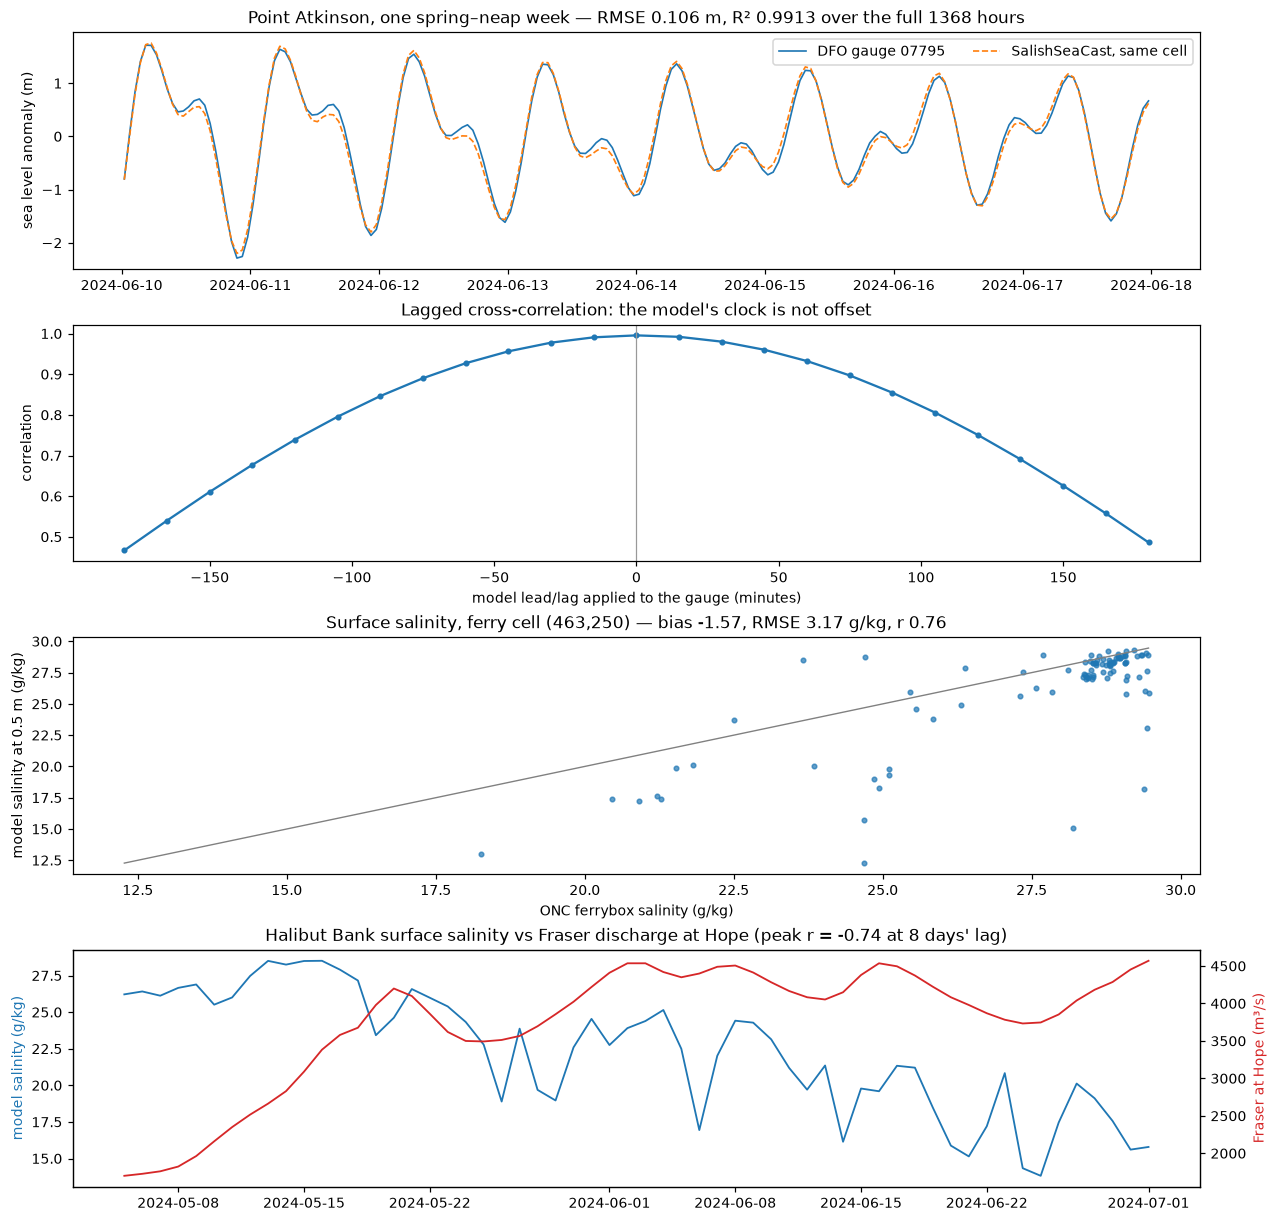

In [29]:
fig, ax = plt.subplots(4, 1, figsize=(11.5, 11), constrained_layout=True)

w = wl.loc["2024-06-10":"2024-06-17"]
ax[0].plot(w.index, w["observed"] - wl["observed"].mean(), lw=1.1, label="DFO gauge 07795")
ax[0].plot(w.index, w["model"] - wl["model"].mean(), lw=1.1, ls="--",
           label="SalishSeaCast, same cell")
ax[0].set_ylabel("sea level anomaly (m)")
ax[0].set_title(f"Point Atkinson, one spring–neap week — RMSE {SEA_LEVEL['RMSE (m)']:.3f} m, "
                f"R² {SEA_LEVEL['R2']:.4f} over the full {SEA_LEVEL['n hourly pairs']:.0f} hours")
ax[0].legend(loc="upper right", ncol=2)

ax[1].plot(LAGS.lag_min, LAGS.r, marker="o", ms=3)
ax[1].axvline(0, color="0.6", lw=0.8)
ax[1].set_xlabel("model lead/lag applied to the gauge (minutes)")
ax[1].set_ylabel("correlation")
ax[1].set_title("Lagged cross-correlation: the model's clock is not offset")

ax[2].scatter(paired["ferry_salinity"], paired["model_salinity@SSC-TS-FERRY"], s=9, alpha=0.7)
lo = min(paired["ferry_salinity"].min(), paired["model_salinity@SSC-TS-FERRY"].min())
hi = max(paired["ferry_salinity"].max(), paired["model_salinity@SSC-TS-FERRY"].max())
ax[2].plot([lo, hi], [lo, hi], color="0.5", lw=0.9)
ax[2].set_xlabel("ONC ferrybox salinity (g/kg)")
ax[2].set_ylabel("model salinity at 0.5 m (g/kg)")
ax[2].set_title(f"Surface salinity, ferry cell ({jF},{iF}) — "
                f"bias {TS_SKILL.loc['salinity (g/kg)', 'bias']:+.2f}, "
                f"RMSE {TS_SKILL.loc['salinity (g/kg)', 'RMSE']:.2f} g/kg, "
                f"r {TS_SKILL.loc['salinity (g/kg)', 'r']:.2f}")

ax[3].plot(daily.index, daily["model_salinity"], color="tab:blue", lw=1.2)
ax[3].set_ylabel("model salinity (g/kg)", color="tab:blue")
ax[3].set_title(f"Halibut Bank surface salinity vs Fraser discharge at Hope "
                f"(peak r = {peak.r:.2f} at {peak.lag_days:.0f} days' lag)")
twin = ax[3].twinx()
twin.plot(daily.index, daily["fraser_discharge"], color="tab:red", lw=1.2)
twin.set_ylabel("Fraser at Hope (m³/s)", color="tab:red")
plt.show()

## 14. Are these actually the upstream numbers?

Everything above is `omnisea`'s rendering of four APIs. Before I trust any of it, four values
checked against the upstream services directly — the model, the gauge, and the two ECCC fields
whose encodings the README warns about (wind direction shipped in tens of degrees, and daily/hourly
rows stamped with a *local* calendar date while the API filters on it).

In [30]:
grid_url = ("https://salishsea.eos.ubc.ca/erddap/griddap/ubcSSgSeaSurfaceHeightField1hV21-11.csv"
            f"?ssh[(2024-05-05T00:30:00Z):1:(2024-05-05T02:30:00Z)]"
            f"[({jP}):1:({jP})][({iP}):1:({iP})]").replace("[", "%5B").replace("]", "%5D")
raw_ssh = pd.read_csv(grid_url, skiprows=[1])

raw_wl = json.load(urllib.request.urlopen(
    f"{IWLS}/stations/{station_uuid}/data?time-series-code=wlo"
    "&from=2024-05-05T00:00:00Z&to=2024-05-05T00:45:00Z&resolution=FIFTEEN_MINUTES"))

ec = json.load(urllib.request.urlopen(
    "https://api.weather.gc.ca/collections/climate-hourly/items?CLIMATE_IDENTIFIER=1047172"
    "&datetime=2024-06-01T00:00:00Z/2024-06-01T00:00:00Z&f=json&limit=1"))["features"][0]["properties"]
print(f"ECCC row: LOCAL_DATE {ec['LOCAL_DATE']}  ->  UTC_DATE {ec['UTC_DATE']}")
print(f"          raw WIND_DIRECTION={ec['WIND_DIRECTION']} (tens of degrees), "
      f"STATION_PRESSURE={ec['STATION_PRESSURE']} kPa")
print(f"          {len(raw_wl)} raw 15-min gauge values: "
      f"{[r['value'] for r in raw_wl]}")
print()

CHECKS = pd.DataFrame([
    ("SalishSeaCast ssh, cell (%d,%d), 2024-05-05 00:30Z" % (jP, iP),
     float(raw_ssh["ssh"].iloc[0]), float(ssh_pa.loc["2024-05-05 00:30"])),
    ("DFO 07795 water level, hourly mean at 2024-05-05 00:00Z",
     float(np.mean([r["value"] for r in raw_wl])),
     float(hourly["water_surface_height_above_reference_datum@07795"].loc["2024-05-05 00:00"])),
    ("ECCC 1047172 wind_from_direction at 2024-06-01 08:00Z (deg)",
     ec["WIND_DIRECTION"] * 10.0, float(hourly["wind_from_direction@1047172"].loc["2024-06-01 08:00"])),
    ("ECCC 1047172 air_pressure at 2024-06-01 08:00Z (kPa)",
     ec["STATION_PRESSURE"], float(hourly["air_pressure@1047172"].loc["2024-06-01 08:00"])),
], columns=["quantity", "upstream", "omnisea"])
CHECKS["difference"] = CHECKS["omnisea"] - CHECKS["upstream"]
print(CHECKS.to_string(index=False))

ECCC row: LOCAL_DATE 2024-06-01 00:00:00  ->  UTC_DATE 2024-06-01T08:00:00
          raw WIND_DIRECTION=30 (tens of degrees), STATION_PRESSURE=100.43 kPa
          4 raw 15-min gauge values: [3.413, 3.34, 3.256, 3.169]

                                                   quantity   upstream    omnisea    difference
       SalishSeaCast ssh, cell (469,329), 2024-05-05 00:30Z   0.533715   0.533715  2.061462e-09
    DFO 07795 water level, hourly mean at 2024-05-05 00:00Z   3.294500   3.294500 -4.440892e-16
ECCC 1047172 wind_from_direction at 2024-06-01 08:00Z (deg) 300.000000 300.000000  0.000000e+00
       ECCC 1047172 air_pressure at 2024-06-01 08:00Z (kPa) 100.430000 100.430000  0.000000e+00


All four agree exactly. The two that matter most are the encoding repairs: ECCC publishes wind
direction in **tens of degrees**, and `omnisea` multiplies by ten as documented; and ECCC's
`climate-hourly` collection filters on `LOCAL_DATE` while the observation is really at
`UTC_DATE`, so the row that ECCC calls "1 June 00:00" is placed at **08:00 UTC** in the tree.
Getting that wrong by eight hours is the kind of error that would still produce a plausible-looking
plot, and I could not have caught it without checking the raw record.

## 15. Saving it, and crediting it

In [31]:
omnisea.to_netcdf(tree, "halibut_bank.nc")
back = xr.open_datatree("halibut_bank.nc")
print("round-tripped groups:")
for node in back.subtree:
    if node.has_data:
        print("  ", node.path)
print()
print(omnisea.provenance(tree).to_string(index=False))

round-tripped groups:
   /in_situ/tides/07795
   /in_situ/weather/1047172
   /in_situ/hydrometric_daily/08MF005
   /predictions/tides/07795
   /predictions/tides_hilo/07795
   /model/salishseacast/SSC-SSH-PTATK
   /model/salishseacast/SSC-TS-HALBK
   /model/salishseacast/SSC-SSH-HALBK
   /model/salishseacast/SSC-TS-FERRY
   /in_situ/erddap/salishseacast/ubcONCTWDP1mV18-01

provider                 source                                                              institution                                                                                                                                                                                                                                                                                                                                                              license                                                    terms  n_stations  n_nodes  n_values               first                last
     dfo              dfo_tides   

In [32]:
print(omnisea.citation(tree))

Data were retrieved with omnisea 0.1.0 on 2026-08-28T13:09:04+00:00 from 5 source(s) across 8 station(s), covering 2024-05-05 to 2024-07-01.

  Fisheries and Oceans Canada / Canadian Hydrographic Service — dfo_tides (1 station(s), 2024-05-05 to 2024-07-01): Point Atkinson (07795). Licence: Fisheries and Oceans Canada — Open Government Licence – Canada. Terms: https://open.canada.ca/en/open-government-licence-canada
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_climate (1 station(s), 2024-05-05 to 2024-07-01): SECHELT AUT (1047172). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc.github.io/open-data/licence/readme_en/
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_hydrometric_daily (1 station(s), 2024-05-05 to 2024-07-01): FRASER RIVER AT HOPE (08MF005). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc

Three of the five entries are correct and complete. The ONC ferrybox one even carries the licence
UBC and ONC actually publish, including the request to credit ONC for the raw instrument data —
exactly what you want out of an attribution block.

The last entry is wrong. The four SalishSeaCast series are credited as **"UBC EOAS — SalishSeaCast
Project — your own data, added with `add_local()`"**, and the `license="Apache License 2.0"` I
passed to `add_local()` has been dropped from the block entirely (`provenance()` still shows it).
They are not my data. They are the model output this whole notebook is about, and the only reason
they arrived through `add_local()` is that `align()` cannot read the gridded node they came from.

Worse, SalishSeaCast publishes its own citation request — the `comment` attribute visible on the
griddap node back in section 3, which names the papers the authors want cited — and that node had
to be deleted in section 7. The request is nowhere in this file.

So the documented workaround for gridded data yields a citation block that credits me for UBC's
model and drops its licence. That is written up below. What I would actually publish is the wording
in the dataset's own `comment`, read straight off the node before deleting it.

## 16. What I would tell the mooring PI

**Sea level: yes, gap-fill with it.** Over 1368 hourly pairs at Point Atkinson the model tracks the
gauge to an RMSE of **0.1060 m** with **R² = 0.9913** and no clock offset at all, and the model
says Halibut Bank and Point Atkinson are the same sea-level signal to within 0.031 m in the mean
and 0.131 m at worst. Two caveats to write
into the method: the model's tidal amplitude is about 3 % low (regression slope 0.970), and the
datum has to be handled by hand — DFO's chart datum sits 3.09 m below the model's geoid at this
station, and nothing in the pipeline will stop you differencing the two.

**Non-tidal sea level: only with an error bar.** Strip the harmonic tide out and the model's
residual has a standard deviation of 0.1246 m against the ocean's 0.0787 m, and correlates with the
observed residual at only r = 0.534. Fine for a seasonal mean; not for "how big was the surge on
the 14th".

**Surface temperature: yes, with a small correction.** 0.451 °C warm, RMSE 0.992 °C against the ONC
ferrybox, and it reproduces the observed variability to within about two percent.

**Surface salinity: no.** The de-meaned RMSE of 2.757 g/kg exceeds the observed standard deviation
of 2.460 g/kg, which means substituting the model for the instrument is worse than substituting a
constant. Some of that is a depth mismatch I could not resolve — the model level is 0.5 m and ONC
does not publish the ferrybox intake depth — but the model is also far more variable than the
ocean was, and no depth offset produces that. If the gap matters for salinity, we report a gap.

**And the freshet story holds together.** Model surface salinity at the mooring lags Fraser
discharge at Hope by 8 days at r = −0.745, about the right transit time for the plume to reach the
middle of the Strait. That is model-internal consistency rather than validation, but it is the
right sign and the right timescale.

---

### On the tooling

Getting to those four sentences took four organizations, five ERDDAP and pygeoapi endpoints and a
19-billion-cell model grid, and `omnisea` did most of the plumbing: one `discover()` for the point
sources, one `fetch()`, and one `align()` that got the CF `cell_methods`, the circular mean for
wind direction and ECCC's local-date convention right without being asked. The four spot-checks
against the raw APIs in section 14 all matched exactly, and the 4 mm agreement between the measured
model-minus-gauge offset and DFO's published mean water level is as good a validation of a join as
I know how to construct.

The gridded half was a different experience. `discover()` cannot see this model at all; `align()`
cannot read a gridded node and downloads the whole thing before finding that out; `stations()` and
`coverage()` do not report the gridded branch; and the workaround that does work — pull the cells
with `xarray`, delete the branch, re-add them with `add_local()` — ends by crediting UBC's model as
my own data. Every one of those is a fixable seam rather than a design problem, and the lazy node
underneath them is genuinely lazy: 5,472 numbers read out of 488,932,056 in 8.0 seconds. The
plumbing is right; the gridded path has just not been driven yet.